In [1]:
import pandas as pd
file_id = '1rm-AAkYYVHcpUu4yLP-D1d2D7FETgD-P'
url = 'https://drive.google.com/uc?id={}'.format(file_id)
data = pd.read_csv(url)

In [2]:
data


,experience,test_score,interview_score,Salary
0,NaN,8.0,8.0,50000
1,NaN,5.0,4.0,22000
2,three,6.0,5.0,30000
3,five,9.0,9.0,55000
4,six,3.0,5.0,13000
5,NaN,2.0,1.0,9000
6,ten,8.0,6.0,48000
7,one,1.0,2.0,500
8,fifteen,9.0,9.0,60000
9,thirteen,7.5,7.5,45000


In [ ]:
'''
1. Objective of the Salary Prediction project
Build a machine‑learning model to predict salary based on:
- Experience
- Test score
- Interview score

 2. Dataset Overview
- Columns: experience, test_score, interview_score, Salary
- Experience values are written as words (“one”, “two”, …)
- Missing values present in all feature columns

 3. Data Cleaning
 Experience Conversion
 Mapped text → numeric (e.g., “one” → 1, “two” → 2 … “fifteen” → 15).

 Handling Missing Values
 Filled missing values using mean imputation for:
- experience
- test_score
- interview_score

 4. Exploratory Data Analysis
Visualizations used:
- Bar charts:
  - Experience vs Test Score
  - Experience vs Interview Score
  - Experience vs Salary
- Line chart: Experience vs Salary
- Joint plot: Test Score vs Interview Score
- Pair plot: All variables
Insight: Salary increases with experience and higher scores.

 5. Model Development
 Feature Matrix(X), Target(y)
- Features: experience, test_score, interview_score
- Target: Salary

 Models Trained
1. Linear Regression
2. Random Forest Regressor

 6. Model Performance
| Metric | Linear Regression |Random Forest
|--------|------------------ |-------------
| MAE 	| 2249.61   	     | 2202.50
| MSE 	| 6,402,944 	     | 6,792,287
| R²  	| 0.9806    	     | 0.9794

Interpretation:
Both models perform extremely well.
Linear Regression has slightly better R².
Random Forest has slightly lower MAE.

 7. Key Takeaways
Salary prediction is strongly influenced by experience and test/interview scores.
Linear Regression performs surprisingly well for such a small dataset.
Random Forest offers competitive performance and may generalize better in larger datasets.
Workflow demonstrates a complete ML pipeline: cleaning → EDA → modeling → evaluation.
Decision Tree and Random Forest are often considered better than Linear Regression for many real‑world cases.
'''

In [4]:
data.shape

(20, 4)

In [5]:
data.columns

Index(['experience', 'test_score', 'interview_score', 'Salary'], dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       15 non-null     object 
 1   test_score       19 non-null     float64
 2   interview_score  19 non-null     float64
 3   Salary           20 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 772.0+ bytes


In [7]:
data.describe()

,test_score,interview_score,Salary
count,19.000000,19.000000,20.000000
mean,5.447368,5.657895,30350.000000
std,2.832817,2.516902,19780.439567
min,1.000000,1.000000,500.000000
25%,3.000000,4.500000,12750.000000
50%,5.000000,6.000000,27500.000000
75%,8.000000,7.750000,48500.000000
max,9.000000,9.000000,60000.000000


In [8]:
data.isnull().sum()

,0
experience,5
test_score,1
interview_score,1
Salary,0


In [9]:
data["experience"].value_counts()

,count
experience,
three,2
five,2
six,2
ten,2
one,2
fifteen,1
thirteen,1
four,1
eleven,1


In [10]:
# data formatting for experience col replacing to numerical
ordinal_values={"one":1,"two":2,"three":3,"four":4,"five":5,"six":6,"seven":7,"eight":8,"nine":9,"ten":10,"eleven":11,"twelve":12,"thirteen":13,"fourteen":14,"fifteen":15}
data["experience"]=data["experience"].map(ordinal_values)

In [11]:
data.describe()

,experience,test_score,interview_score,Salary
count,15.000000,19.000000,19.000000,20.000000
mean,7.000000,5.447368,5.657895,30350.000000
std,4.488079,2.832817,2.516902,19780.439567
min,1.000000,1.000000,1.000000,500.000000
25%,3.500000,3.000000,4.500000,12750.000000
50%,6.000000,5.000000,6.000000,27500.000000
75%,10.500000,8.000000,7.750000,48500.000000
max,15.000000,9.000000,9.000000,60000.000000


In [12]:
# replacing nulls in experience with mean value or avg of experiences
mean_experience=data["experience"].mean()
data["experience"].fillna(mean_experience,inplace=True)  # making it permanent in place

/tmp/ipykernel_168/3859034338.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["experience"].fillna(mean_experience,inplace=True)  # making it permanent in place


In [13]:
# Handling the missing values in test_score column
mean_test_score=data["test_score"].mean()
data["test_score"].fillna(mean_test_score,inplace=True)

/tmp/ipykernel_168/129675747.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["test_score"].fillna(mean_test_score,inplace=True)


In [14]:
# Handling the missing value in interview_score
mean_interview_score=data["interview_score"].mean()
data["interview_score"].fillna(mean_interview_score,inplace=True)

/tmp/ipykernel_168/1933175220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["interview_score"].fillna(mean_interview_score,inplace=True)


In [15]:
data.head()

,experience,test_score,interview_score,Salary
0,7.0,8.0,8.0,50000
1,7.0,5.0,4.0,22000
2,3.0,6.0,5.0,30000
3,5.0,9.0,9.0,55000
4,6.0,3.0,5.0,13000


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

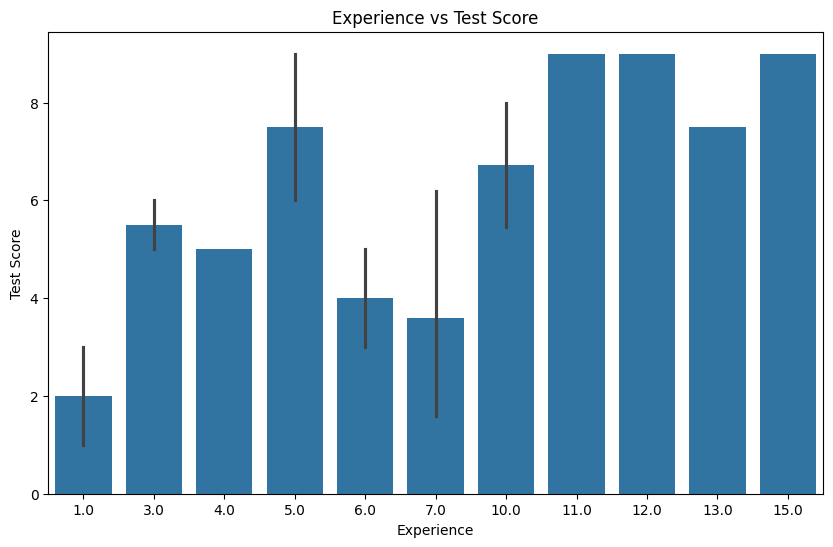

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=data["experience"],y=data["test_score"])
plt.title("Experience vs Test Score")
plt.xlabel("Experience")
plt.ylabel("Test Score")
plt.show()

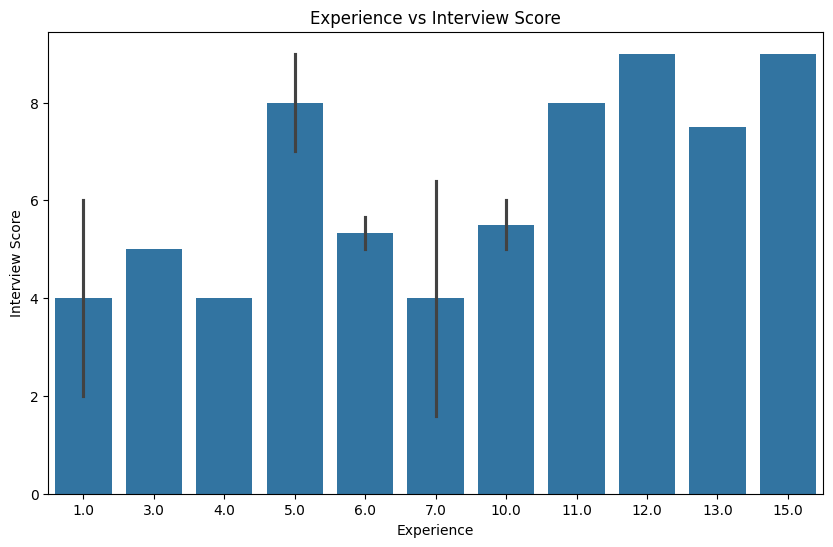

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=data["experience"],y=data["interview_score"])
plt.title("Experience vs Interview Score")
plt.xlabel("Experience")
plt.ylabel("Interview Score")
plt.show()

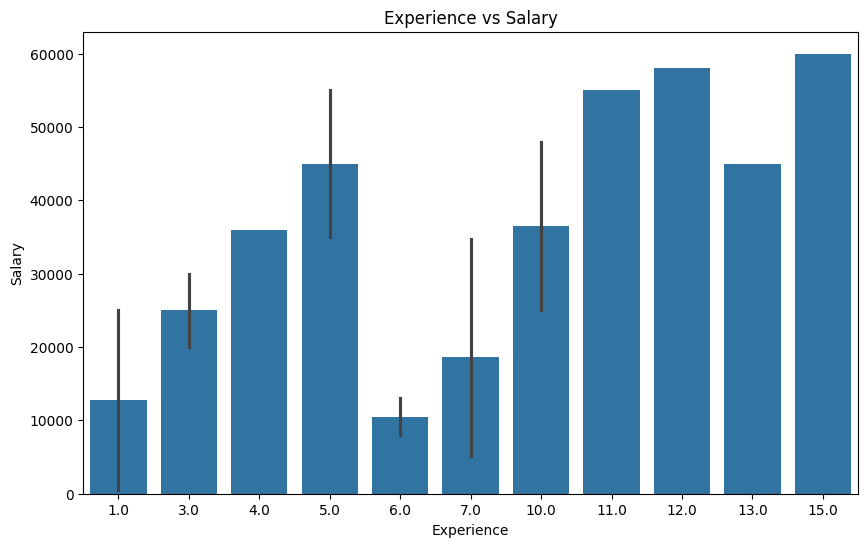

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x=data["experience"],y=data["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

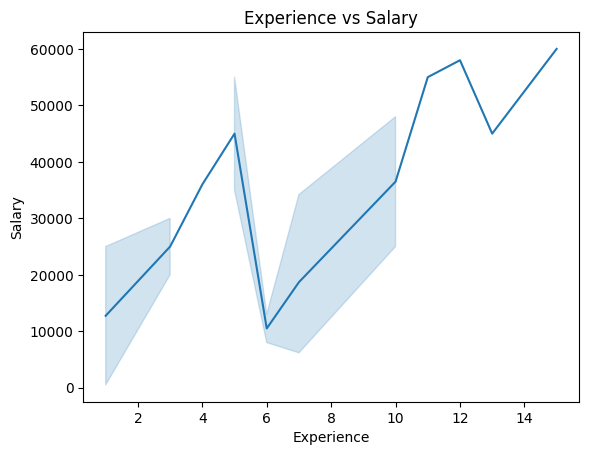

In [20]:
sns.lineplot(x=data["experience"],y=data["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()


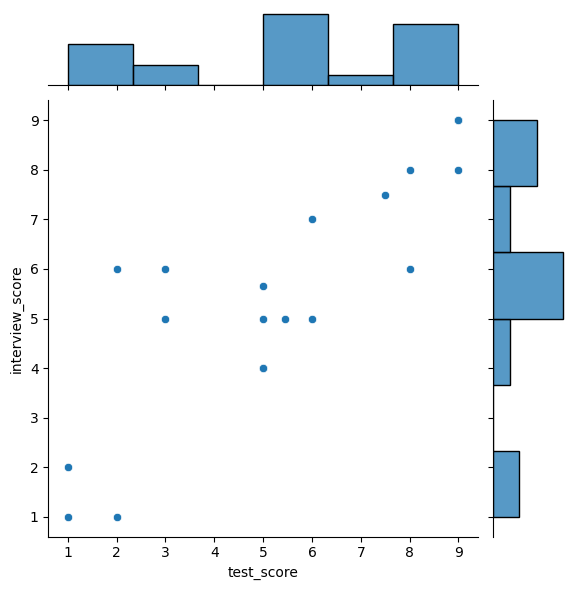

In [21]:
sns.jointplot(x=data["test_score"],y=data["interview_score"])
plt.show()

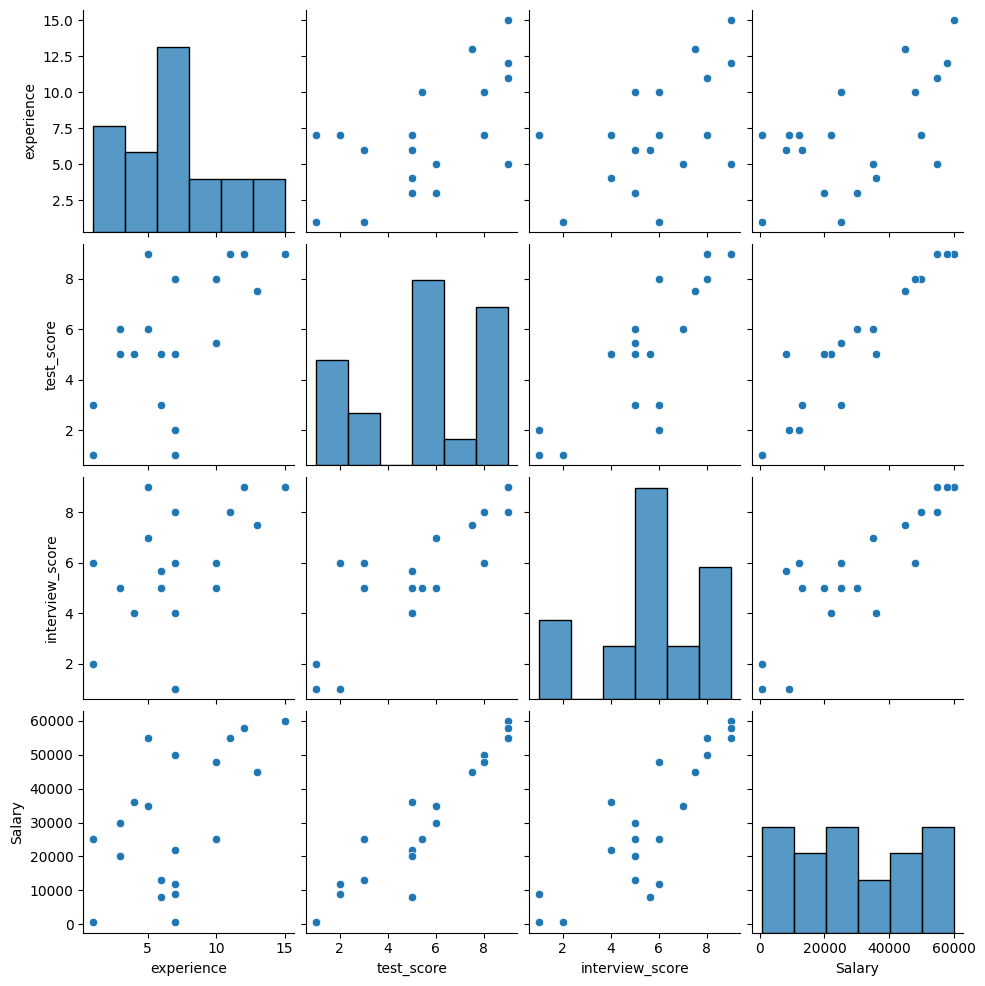

In [22]:
sns.pairplot(data)
plt.show()

In [23]:
# Defining features and target
features=data.drop(columns=["Salary"],axis=1)
target=data["Salary"]

In [24]:
# Data splitting
from sklearn.model_selection import train_test_split
features_train,features_test,target_train,target_test=train_test_split(features,target,test_size=0.2,random_state=42)


In [25]:
# model training
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(features_train,target_train)

LinearRegression()

In [26]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(features_train,target_train)

RandomForestRegressor()

In [27]:
# model evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
linear_pred=lr_model.predict(features_test)
linear_mae=mean_absolute_error(target_test,linear_pred)
linear_mse=mean_squared_error(target_test,linear_pred)
linear_r2=r2_score(target_test,linear_pred)
print("Linear Regression Metrics:")
print("Mean Absolute Error:",linear_mae)
print("Mean Squared Error:",linear_mse)
print("R2 Score:",linear_r2)

Linear Regression Metrics:
Mean Absolute Error: 2249.6111492147056
Mean Squared Error: 6402944.506927436
R2 Score: 0.9806374764485278


In [28]:
rf_pred=rf_model.predict(features_test)
rf_mae=mean_absolute_error(target_test,rf_pred)
rf_mse=mean_squared_error(target_test,rf_pred)
r2_score=r2_score(target_test,rf_pred)
print("Random Forest Regression Metrics:")
print("Mean Absolute Error:",rf_mae)
print("Mean Squared Error:",rf_mse)
print("R2 Score:",r2_score)

Random Forest Regression Metrics:
Mean Absolute Error: 2202.5
Mean Squared Error: 6792287.5
R2 Score: 0.979460102060102


In [29]:
# decision tree and Random forest are considered better than LR or Linear Regression